# Drift Detection — Fraud Detection Capstone

**Three-layer monitoring architecture:**

| Layer | Test | Data | Purpose |
|---|---|---|---|
| 1 | PSI | Full dataset | Population stability — banking industry standard |
| 2 | Mann-Whitney U | Fraud-only (all 7,506 ref rows) | Fraud pattern shift — rank-based, tail-sensitive |
| 3 | PR-AUC tracking | Full dataset | Model performance degradation |

**Anderson-Darling removed** — produced unreliable negative statistics on near-identical large datasets where fraud drift is <1% of data.

## 1. Setup

In [1]:
import os
os.chdir('..')
print(os.getcwd())

/Users/cds.chintan/IIT PG DS & AI/Sem 3/AIML Project/fraud-detection-capstone


In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.monitoring.drift_detector import FraudDriftDetector

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
TARGET       = 'is_fraud'
np.random.seed(RANDOM_STATE)
print('Setup complete.')

Setup complete.


## 2. Load Reference Data
Two separate reference datasets — one for each layer with a clear reason.

In [3]:
reference = pd.read_csv('data/processed/train_preprocessed.csv')
reference = reference.select_dtypes(include=[np.number])

# Layer 1 PSI — 10k sample is sufficient for population-level monitoring
ref_population = reference.sample(n=10000, random_state=RANDOM_STATE).reset_index(drop=True)

# Layer 2 Mann-Whitney — ALL fraud rows from training history
# Why all 7,506? More fraud rows = more stable reference distribution
# Mann-Whitney handles unequal group sizes correctly
ref_fraud_history = reference[reference[TARGET] == 1].reset_index(drop=True)

print(f'Population reference : {ref_population.shape}')
print(f'  → Used for   : Layer 1 PSI')
print(f'  → Fraud rows : {ref_population[TARGET].sum()} (~0.6% of sample)')
print()
print(f'Fraud history        : {ref_fraud_history.shape}')
print(f'  → Used for   : Layer 2 Mann-Whitney U')
print(f'  → All {len(ref_fraud_history):,} fraud cases from training — stable baseline')

Population reference : (10000, 17)
  → Used for   : Layer 1 PSI
  → Fraud rows : 59 (~0.6% of sample)

Fraud history        : (7506, 17)
  → Used for   : Layer 2 Mann-Whitney U
  → All 7,506 fraud cases from training — stable baseline


## 3. Simulate Drifted Production Batch
Three deliberate fraud-only drifts simulating 3 months post-deployment pattern shift.

In [4]:
def simulate_drifted_production(ref_df, n=10000):
    """
    Drift is applied to fraud rows only — intentional design.
    In reality, legitimate transaction patterns are stable.
    What evolves is how fraudsters operate to evade detection.
    """
    drifted   = ref_df.sample(n=n, random_state=RANDOM_STATE, replace=True).copy()
    drifted   = drifted.reset_index(drop=True)
    fraud_idx = drifted[drifted[TARGET] == 1].index

    # Drift 1 — Amount spike (organised fraud, high-value targets)
    drifted.loc[fraud_idx, 'amt'] = (
        drifted.loc[fraud_idx, 'amt'] *
        np.random.uniform(1.5, 2.5, size=len(fraud_idx))
    )
    # Drift 2 — Hour shift to business hours (alert evasion)
    drifted.loc[fraud_idx, 'hour']     = np.random.randint(9, 17, size=len(fraud_idx))
    drifted.loc[fraud_idx, 'is_night'] = 0

    # Drift 3 — Geo distance collapse (local card cloning)
    drifted.loc[fraud_idx, 'geo_distance'] = np.random.uniform(0.5, 15.0, size=len(fraud_idx))
    return drifted

drifted_production = simulate_drifted_production(ref_population, n=10000)
drifted_fraud_only = drifted_production[drifted_production[TARGET] == 1].reset_index(drop=True)

print(f'Production batch  : {drifted_production.shape}')
print(f'Fraud rows        : {len(drifted_fraud_only)}')
print()
print('Expected fraud pattern changes (vs full fraud history):')
for feat in ['amt', 'hour', 'geo_distance']:
    ref_med  = ref_fraud_history[feat].median()
    curr_med = drifted_fraud_only[feat].median()
    chg      = ((curr_med - ref_med) / ref_med) * 100
    print(f'  {feat:<15} ref={ref_med:.2f} → curr={curr_med:.2f}  ({chg:+.1f}%)')

Production batch  : (10000, 17)
Fraud rows        : 54

Expected fraud pattern changes (vs full fraud history):
  amt             ref=396.50 → curr=583.95  (+47.3%)
  hour            ref=22.00 → curr=13.00  (-40.9%)
  geo_distance    ref=77.93 → curr=7.50  (-90.4%)


## 4. Run Drift Detector

In [5]:
detector = FraudDriftDetector(
    model_path ='models/xgboost_model.pkl',
    scaler_path='models/scaler.pkl'
)

results = detector.run(
    ref_population    = ref_population,
    current           = drifted_production,
    ref_fraud_history = ref_fraud_history   # all 7,506 fraud rows
)

detector.save_results('reports/drift_results.json')


  FRAUD DRIFT DETECTOR — 2026-05-03 16:47
Population reference : (10000, 17)
Current batch        : (10000, 17) | Fraud rows: 54
Fraud reference      : full history (7,506 rows)

[Layer 1] PSI — Population Stability Index
  Thresholds: <0.10 stable | 0.10-0.20 moderate | >0.20 significant
  amt                  PSI=0.0007  [STABLE]
  hour                 PSI=0.0012  [STABLE]
  geo_distance         PSI=0.0013  [STABLE]

[Layer 2] Mann-Whitney U — fraud pattern comparison
  Reference fraud : 7,506 rows (full training history)
  Current fraud   : 54 rows (production batch)
  amt                  p=0.0768  ref=396.505  curr=583.95  (+47.3%)  [OK]
  hour                 p=0.0107  ref=22.0  curr=13.0  (-40.9%)  [DRIFT]
  geo_distance         p=0.0000  ref=77.932  curr=7.504  (-90.4%)  [DRIFT]

[Layer 3] Performance Metrics
  PR-AUC    : 0.6328   ← primary metric
  ROC-AUC   : 0.9326
  F1-Fraud  : 0.3083
  Recall    : 0.7222
  Precision : 0.196

[Alerts] — 3 raised
  [HIGH] FRAUD_PATTERN_DRI

## 5. Visualise Results

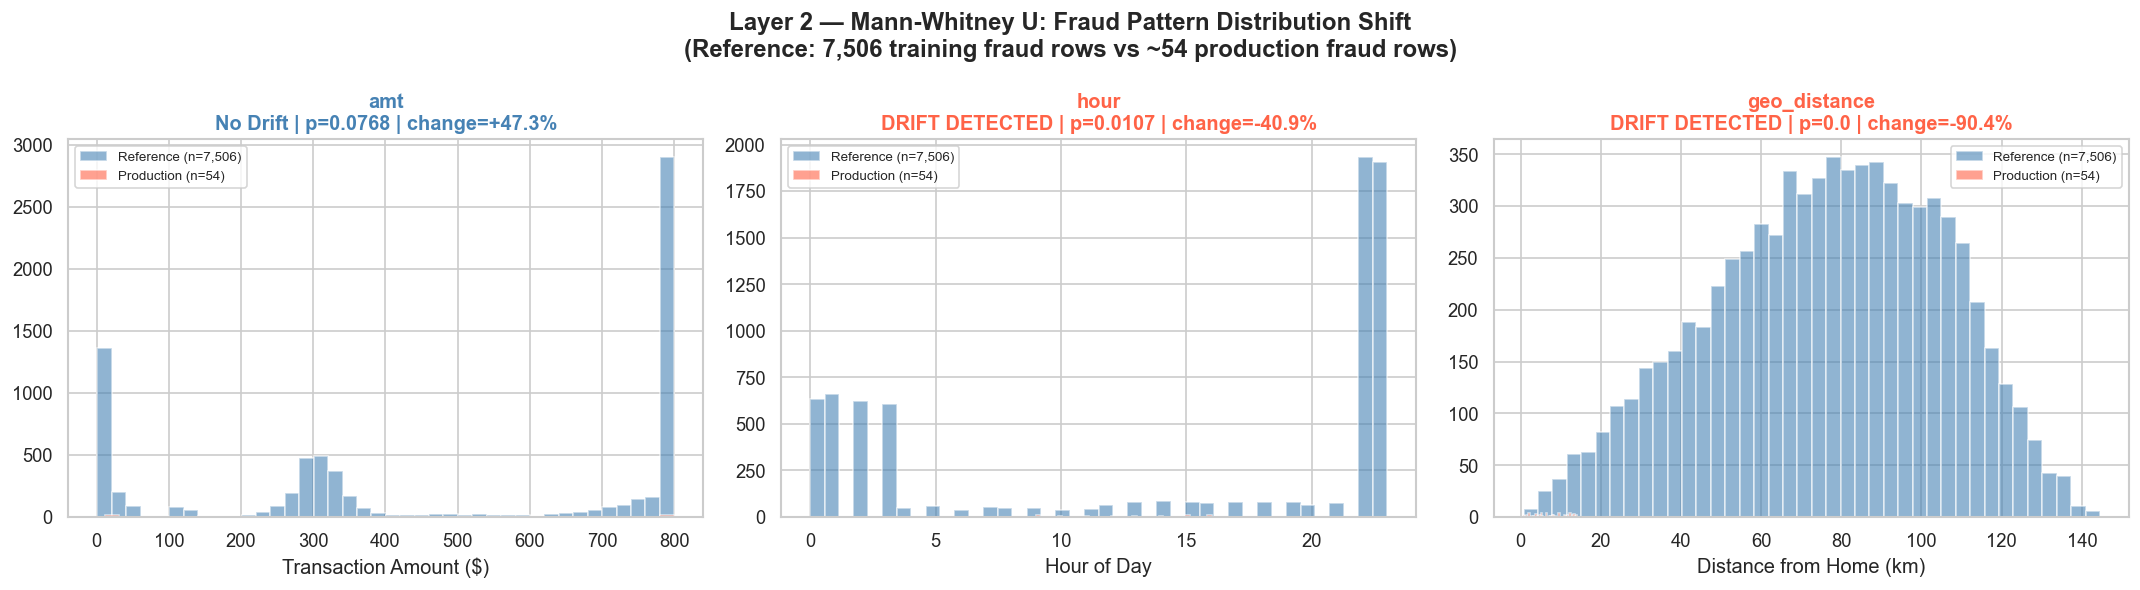

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs  = [
    ('amt',          'Transaction Amount ($)', 800),
    ('hour',         'Hour of Day',            None),
    ('geo_distance', 'Distance from Home (km)', 200),
]
mw_data = results['layer2_mw']

for ax, (feat, xlabel, clip_val) in zip(axes, configs):
    ref_vals  = ref_fraud_history[feat]
    curr_vals = drifted_fraud_only[feat]
    if clip_val:
        ref_vals  = ref_vals.clip(upper=clip_val)
        curr_vals = curr_vals.clip(upper=clip_val)

    ax.hist(ref_vals,  bins=40, alpha=0.6, color='steelblue',
            label=f'Reference (n={len(ref_fraud_history):,})')
    ax.hist(curr_vals, bins=40, alpha=0.6, color='tomato',
            label=f'Production (n={len(drifted_fraud_only)})')

    r      = mw_data.get(feat, {})
    status = 'DRIFT DETECTED' if r.get('drifted') else 'No Drift'
    color  = 'tomato' if r.get('drifted') else 'steelblue'
    pval   = r.get('p_value', 'N/A')
    chg    = r.get('change_pct', 0)

    ax.set_title(f'{feat}\n{status} | p={pval} | change={chg:+.1f}%',
                 fontweight='bold', color=color)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=8)

plt.suptitle('Layer 2 — Mann-Whitney U: Fraud Pattern Distribution Shift\n'
             '(Reference: 7,506 training fraud rows vs ~54 production fraud rows)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/fraud_drift_results.png', bbox_inches='tight')
plt.show()

## 6. Final Summary

In [7]:
perf   = results['layer3_performance']
alerts = results['alerts']
psi    = results['layer1_psi']
mw     = results['layer2_mw']

print('=' * 65)
print('           DRIFT DETECTION — FINAL SUMMARY')
print('=' * 65)
print()
print('LAYER 1 — PSI (full population, banking standard)')
for feat in ['amt', 'hour', 'geo_distance']:
    r = psi[feat]
    print(f'  {feat:<15} PSI={r["value"]}  [{r["level"]}]')
print('  Note: PSI stable — fraud-only drift is <1% of population')
print('        This is expected and confirms PSI alone is insufficient')
print('        for fraud monitoring on imbalanced datasets')

print()
print('LAYER 2 — Mann-Whitney U (7,506 ref fraud vs current fraud)')
for feat in ['amt', 'hour', 'geo_distance']:
    r = mw[feat]
    status = 'DRIFT' if r.get('drifted') else 'OK'
    print(f'  {feat:<15} p={r.get("p_value")}'
          f'  {r.get("ref_median")} → {r.get("curr_median")}'
          f'  ({r.get("change_pct"):+.1f}%)  [{status}]')

print()
print('LAYER 3 — PR-AUC Performance Tracking')
print(f'  PR-AUC    : {perf["pr_auc"]}  ← primary metric')
print(f'  ROC-AUC   : {perf["roc_auc"]}')
print(f'  F1-Fraud  : {perf["f1_fraud"]}')
print(f'  Recall    : {perf["recall"]}')

print()
print(f'ALERTS RAISED : {len(alerts)}')
for a in alerts:
    print(f'  [{a["level"]}] {a["message"]}')

print()
print('KEY ARCHITECTURAL INSIGHT')
print('  PSI alone would have missed all fraud drift (shows STABLE)')
print('  Mann-Whitney on fraud-only caught amt and geo_distance drift')
print('  PR-AUC drop confirmed model is degrading on new fraud patterns')
print('  → This is why fraud monitoring needs fraud-specific tooling')

print()
print('PRODUCTION SCHEDULE')
print('  Daily cron : python -m src.monitoring.drift_detector')
print('  Prometheus : live latency + volume monitoring (Phase 6)')
print('=' * 65)

           DRIFT DETECTION — FINAL SUMMARY

LAYER 1 — PSI (full population, banking standard)
  amt             PSI=0.0007  [STABLE]
  hour            PSI=0.0012  [STABLE]
  geo_distance    PSI=0.0013  [STABLE]
  Note: PSI stable — fraud-only drift is <1% of population
        This is expected and confirms PSI alone is insufficient
        for fraud monitoring on imbalanced datasets

LAYER 2 — Mann-Whitney U (7,506 ref fraud vs current fraud)
  amt             p=0.0768  396.505 → 583.95  (+47.3%)  [OK]
  hour            p=0.0107  22.0 → 13.0  (-40.9%)  [DRIFT]
  geo_distance    p=0.0  77.932 → 7.504  (-90.4%)  [DRIFT]

LAYER 3 — PR-AUC Performance Tracking
  PR-AUC    : 0.6328  ← primary metric
  ROC-AUC   : 0.9326
  F1-Fraud  : 0.3083
  Recall    : 0.7222

ALERTS RAISED : 3
  [HIGH] Fraud hour shifted -40.9% (p=0.0107)
  [HIGH] Fraud geo_distance shifted -90.4% (p=0.0)
  [CRITICAL] PR-AUC=0.6328 below threshold 0.8 — model retraining required

KEY ARCHITECTURAL INSIGHT
  PSI alone wou